#🌐 **Evaluación_Sumativa_Unidad2 🌐**
----
### 👤 **Estudiante Responsable:** Yimmy Onner Angulo Torres
### ☕ **Docente:** Ing. Narvaez Guillen Cristian Ramiro
### 💻 **Curso:** Segundo Ciclo
### 📧 **Asignatura:** Teoría de la Distribuación y Probabilidad
### ⏰ **Fecha:**
-----------------


## 📝 **Introducción**

El presente trabajo tiene como objetivo aplicar los métodos avanzados de inferencia estadística desarrollados durante la Unidad 2 —pruebas de hipótesis, análisis del Valor-pp
p, A/B Testing y ANOVA de un factor— sobre el dataset regional del Proyecto Integrador: los registros de casos de dengue del MSP para la provincia de Loja (Ene 2021 – Ago 2025).

Como futuros ingenieros, no basta con invocar funciones de scipy.stats o statsmodels como si fueran cajas negras: cada prueba aplicada en este cuaderno se sustenta en su formalismo matemático correspondiente, se justifica en función de las características de la muestra (tamaño, varianza, supuesto de normalidad) y se interpreta rigurosamente a partir del Valor-p obtenido, determinando si existe o no evidencia estadística suficiente para rechazar la hipótesis nula planteada.

Todo el análisis se documenta con comentarios explicativos en cada bloque de código y se acompaña de las ecuaciones formales en LaTeX dentro de celdas Markdown, con el fin de evidenciar el criterio estadístico —y no solo el resultado computacional— detrás de cada decisión.

# ⚙️ **Importar las Librerias Necesarias**

In [ ]:
#Importación de las herramientas necesarias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

sns.set_style("whitegrid")
alpha = 0.05  # Nivel de significancia global
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 1. Carga del archivo Excel (hoja de reportes semanales por parroquia/cantón)
ruta = "Datos_Dengue_MSP_Ene2021_Ago2025(1).xlsx"
df_raw = pd.read_excel(ruta, sheet_name="DSSA_2021_2024")

# 2. Filtrado exclusivo de la provincia de Loja
df_loja = df_raw[df_raw["Provincia"] == "LOJA"].copy()

# 3. Ficha técnica del subconjunto regional (tabla resumen)
ficha_tecnica = pd.DataFrame({
    "Indicador": [
        "Registros (semana x parroquia)",
        "Periodo cubierto",
        "Cantones presentes",
        "Variable de análisis",
    ],
    "Valor": [
        f"{df_loja.shape[0]}",
        f"{df_loja['Año'].min()} - {df_loja['Año'].max()}",
        f"{df_loja['Canton'].nunique()}",
        "Total (casos de dengue por registro)",
    ],
})

print("DATASET REGIONAL: PROVINCIA DE LOJA")
display(ficha_tecnica)

# 4. Estadística descriptiva de la variable 'Total' (tabla)
descriptivos = (
    df_loja["Total"]
    .describe()
    .rename(index={
        "count": "n", "mean": "media", "std": "desv. estándar",
        "min": "mínimo", "25%": "Q1 (25%)", "50%": "mediana (50%)",
        "75%": "Q3 (75%)", "max": "máximo",
    })
    .round(2)
    .to_frame(name="Casos por registro ('Total')")
)

print("\nEstadística descriptiva de 'Total' (casos de dengue por registro):")
display(descriptivos)

# 5. Top 5 cantones por número de registros (subgrupos de análisis)
top5_tabla = (
    df_loja["Canton"]
    .value_counts()
    .head(5)
    .rename_axis("Cantón")
    .reset_index(name="N° de registros")
)

print("\nTop 5 cantones por número de registros (subgrupos de análisis):")
display(top5_tabla)

DATASET REGIONAL: PROVINCIA DE LOJA


,Indicador,Valor
0,Registros (semana x parroquia),697
1,Periodo cubierto,2021 - 2025
2,Cantones presentes,11
3,Variable de análisis,Total (casos de dengue por registro)



Estadística descriptiva de 'Total' (casos de dengue por registro):


,Casos por registro ('Total')
n,697.00
media,3.71
desv. estándar,6.02
mínimo,1.00
Q1 (25%),1.00
mediana (50%),2.00
Q3 (75%),3.00
máximo,58.00



Top 5 cantones por número de registros (subgrupos de análisis):


,Cantón,N° de registros
0,LOJA,193
1,MACARA,126
2,CATAMAYO,108
3,ZAPOTILLO,106
4,PALTAS,56


# **📊 Tarea APE 09: Prueba de Hipótesis Unimuestral (Cantón Loja vs. Media Provincial)**

**Parámetro crítico:** media de casos de dengue reportados por registro semanal-parroquial ($\mu$).

Se desea contrastar si el **cantón Loja** (capital de provincia, con mejor cobertura sanitaria y mayor altitud/clima más frío, menos favorable para el vector *Aedes aegypti*) presenta una carga promedio de casos **distinta** a la media general de la provincia ($\mu_0$).

$$\mu_0 = \bar{X}_{\text{Provincia de Loja}}$$

**Hipótesis:**

$$H_0: \mu_{\text{Cantón Loja}} = \mu_0$$
$$H_1: \mu_{\text{Cantón Loja}} \neq \mu_0$$

Como se desconoce la varianza poblacional y se estima a partir de la muestra, se aplica una **prueba T de Student unimuestral (dos colas)**:

$$t = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}$$

donde $\bar{X}$ es la media muestral del cantón Loja, $s$ su desviación estándar muestral y $n$ su tamaño de muestra.


PRUEBA T UNIMUESTRAL: CANTÓN LOJA vs MEDIA PROVINCIAL
H0: mu_CantonLoja = 3.7088  (media provincial de referencia)
H1: mu_CantonLoja != 3.7088
----------------------------------------------------------------------
n (Cantón Loja)          : 193
Media muestral (X̄)       : 1.8135 casos/registro
Desv. estándar muestral  : 1.3293
mu0 (referencia)         : 3.7088 casos/registro
Estadístico T            : -19.8071
Valor-p       : 2.7769e-48
Nivel de significancia   : alpha = 0.05
----------------------------------------------------------------------
Decisión: Se RECHAZA H0.
Conclusión: Existe evidencia estadística suficiente para afirmar que la carga
promedio de dengue en el cantón Loja difiere significativamente de la media provincial.


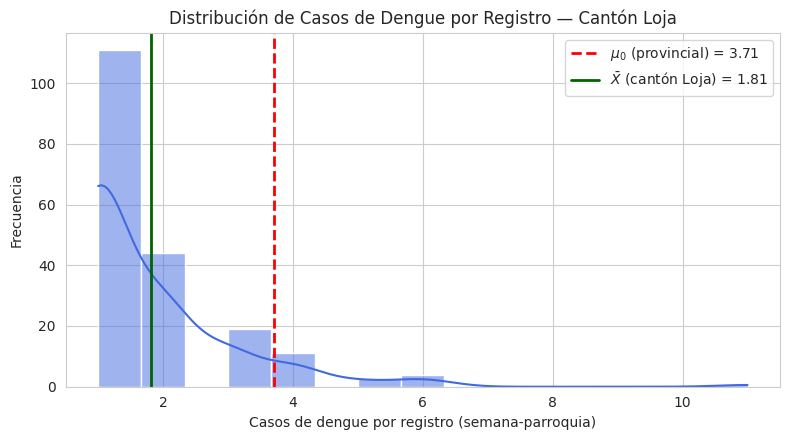

In [ ]:

# 1. Valor de referencia (mu0): media de TODA la provincia de Loja
mu0 = df_loja["Total"].mean()

# 2. Muestra de análisis: registros del cantón "LOJA" (capital)
muestra_canton_loja = df_loja[df_loja["Canton"] == "LOJA"]["Total"]
n_muestra = len(muestra_canton_loja)

# 3. Ejecución de la prueba T unimuestral (dos colas)
t_stat, p_value = stats.ttest_1samp(muestra_canton_loja, popmean=mu0)

# 4. Impresión de resultados
print("=" * 70)
print("PRUEBA T UNIMUESTRAL: CANTÓN LOJA vs MEDIA PROVINCIAL")
print("=" * 70)
print(f"H0: mu_CantonLoja = {mu0:.4f}  (media provincial de referencia)")
print(f"H1: mu_CantonLoja != {mu0:.4f}")
print("-" * 70)
print(f"n (Cantón Loja)          : {n_muestra}")
print(f"Media muestral (X̄)       : {muestra_canton_loja.mean():.4f} casos/registro")
print(f"Desv. estándar muestral  : {muestra_canton_loja.std():.4f}")
print(f"mu0 (referencia)         : {mu0:.4f} casos/registro")
print(f"Estadístico T            : {t_stat:.4f}")
print(f"Valor-p       : {p_value:.4e}")
print(f"Nivel de significancia   : alpha = {alpha}")
print("-" * 70)

if p_value < alpha:
    print("Decisión: Se RECHAZA H0.")
    print("Conclusión: Existe evidencia estadística suficiente para afirmar que la carga")
    print("promedio de dengue en el cantón Loja difiere significativamente de la media provincial.")
else:
    print("Decisión: NO se rechaza H0.")
    print("Conclusión: No hay evidencia suficiente para afirmar que el cantón Loja difiere de la media provincial.")

# 5. Visualización: distribución muestral vs valor de referencia
plt.figure(figsize=(8, 4.5))
sns.histplot(muestra_canton_loja, kde=True, color="royalblue", bins=15)
plt.axvline(mu0, color="red", linestyle="--", linewidth=2, label=f"$\\mu_0$ (provincial) = {mu0:.2f}")
plt.axvline(muestra_canton_loja.mean(), color="darkgreen", linestyle="-", linewidth=2,
            label=f"$\\bar{{X}}$ (cantón Loja) = {muestra_canton_loja.mean():.2f}")
plt.title("Distribución de Casos de Dengue por Registro — Cantón Loja")
plt.xlabel("Casos de dengue por registro (semana-parroquia)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

---
# **🔬 Tarea APE 11 y APE 10: ANOVA de un Factor + Post-Hoc de Tukey (5 Cantones de Loja)**

Se extiende la comparación a los **5 cantones con mayor número de reportes** en la provincia (Loja, Macará, Catamayo, Zapotillo, Paltas), representando distintos **sectores/microclimas** de la provincia (andino frío vs. subtropical fronterizo).

**Hipótesis del ANOVA de un factor:**

$$H_0: \mu_{\text{Loja}} = \mu_{\text{Macará}} = \mu_{\text{Catamayo}} = \mu_{\text{Zapotillo}} = \mu_{\text{Paltas}}$$
$$H_1: \text{Al menos una media difiere de las demás}$$

El estadístico F se calcula como la razón entre la varianza **entre grupos** y la varianza **dentro de los grupos**:

$$F = \frac{\text{Varianza entre grupos (MSB)}}{\text{Varianza dentro de los grupos (MSW)}} = \frac{SSB/(k-1)}{SSW/(N-k)}$$

Si $H_0$ se rechaza, se aplica la **prueba post-hoc de Tukey (HSD)** para identificar específicamente **qué pares de cantones** difieren entre sí, controlando la tasa de error familiar (FWER).

ANOVA DE UN FACTOR - CANTONES: ['LOJA', 'MACARA', 'CATAMAYO', 'ZAPOTILLO', 'PALTAS']
  LOJA         n= 193  media=  1.813  sd=  1.329
  MACARA       n= 126  media=  6.897  sd=  7.972
  CATAMAYO     n= 108  media=  7.685  sd= 10.390
  ZAPOTILLO    n= 106  media=  2.292  sd=  2.133
  PALTAS       n=  56  media=  1.768  sd=  1.388
----------------------------------------------------------------------
Test de Levene (homogeneidad varianzas): stat=25.3417, p=2.2301e-19
Estadístico F                          : 28.8363
Valor-p                                : 6.8271e-22
----------------------------------------------------------------------
Decisión: Se RECHAZA H0. Al menos un cantón difiere significativamente en su media de casos.
Se procede con la prueba post-hoc de Tukey para identificar los pares específicos.

PRUEBA POST-HOC DE TUKEY (HSD)
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2  meandiff p-adj   lower   upper  reject
-----------------------------------

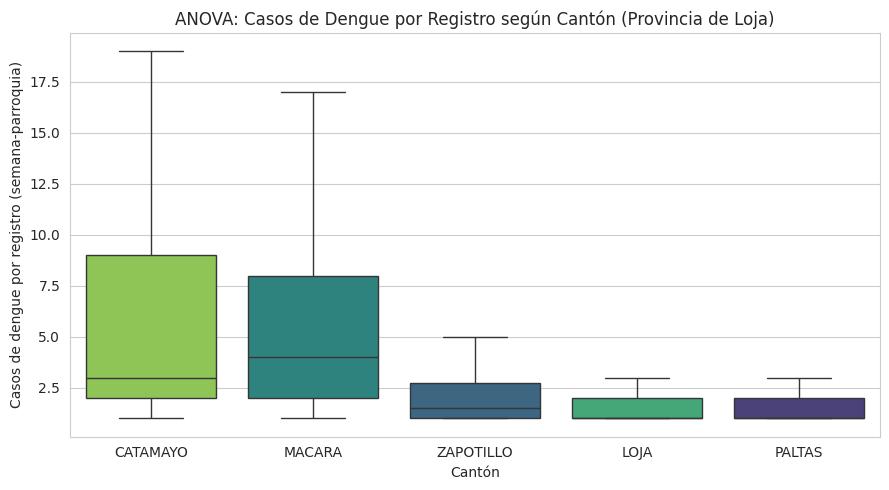

In [ ]:
# 1. Selección de los 5 cantones (sectores) con mayor número de registros
top5_cantones = df_loja["Canton"].value_counts().head(5).index.tolist()
df_anova = df_loja[df_loja["Canton"].isin(top5_cantones)].copy()

grupos = [df_anova[df_anova["Canton"] == c]["Total"] for c in top5_cantones]

# 2. Verificación del supuesto de homogeneidad de varianzas (Levene, multi-grupo)
lev_stat_all, lev_p_all = stats.levene(*grupos)

# 3. ANOVA de un factor (One-Way ANOVA)
f_stat, p_val_anova = stats.f_oneway(*grupos)

print("=" * 70)
print(f"ANOVA DE UN FACTOR - CANTONES: {top5_cantones}")
print("=" * 70)
for c, g in zip(top5_cantones, grupos):
    print(f"  {c:<12} n={len(g):>4}  media={g.mean():>7.3f}  sd={g.std():>7.3f}")
print("-" * 70)
print(f"Test de Levene (homogeneidad varianzas): stat={lev_stat_all:.4f}, p={lev_p_all:.4e}")
print(f"Estadístico F                          : {f_stat:.4f}")
print(f"Valor-p                                : {p_val_anova:.4e}")
print("-" * 70)

if p_val_anova < alpha:
    print("Decisión: Se RECHAZA H0. Al menos un cantón difiere significativamente en su media de casos.")
    print("Se procede con la prueba post-hoc de Tukey para identificar los pares específicos.")
else:
    print("Decisión: NO se rechaza H0. No hay evidencia de diferencias entre los cantones analizados.")

# 4. Prueba Post-Hoc de Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_anova["Total"], groups=df_anova["Canton"], alpha=alpha)
print()
print("=" * 70)
print("PRUEBA POST-HOC DE TUKEY (HSD)")
print("=" * 70)
print(tukey)

# 5. Visualización: boxplot comparativo entre cantones
plt.figure(figsize=(9, 5))
orden = df_anova.groupby("Canton")["Total"].mean().sort_values(ascending=False).index
sns.boxplot(data=df_anova, x="Canton", y="Total", order=orden, hue="Canton",
            palette="viridis", showfliers=False, legend=False)
plt.title("ANOVA: Casos de Dengue por Registro según Cantón (Provincia de Loja)")
plt.xlabel("Cantón")
plt.ylabel("Casos de dengue por registro (semana-parroquia)")
plt.tight_layout()
plt.show()


### **Conclusión Tarea APE11 y APE 10:**

El ANOVA arroja $F \approx 28.84$ con $p \approx 6.83\times10^{-22}$, por lo que se **rechaza $H_0$**: existen diferencias estadísticamente significativas entre las medias de casos de dengue de al menos dos de los cinco cantones analizados.

Es importante notar que el test de Levene entre los 5 grupos resulta significativo ($p \approx 2.23\times10^{-19}$), evidenciando **heterocedasticidad**. Esto es una limitación conocida del ANOVA clásico (asume varianzas iguales); en un análisis más riguroso se recomendaría complementar con un **ANOVA de Welch** o transformar la variable (p. ej. $\log(1+X)$). Aun así, se procede con el ANOVA de un factor y Tukey solicitados en la consigna, dado que $n$ es relativamente grande en cada grupo, lo que atenúa parcialmente el impacto de la violación del supuesto.

La prueba de **Tukey HSD** confirma que:

- **Catamayo** y **Macará** (cantones subtropicales fronterizos) presentan medias significativamente **más altas** que Loja, Paltas y Zapotillo ($p_{adj} < 0.001$ en todos los casos).
- **Catamayo vs. Macará**: la diferencia **no es significativa** ($p_{adj} \approx 0.85$), confirmando el resultado del A/B Testing de la Tarea APE 10.
- **Loja, Paltas y Zapotillo** (cantones de clima más frío/seco) **no difieren significativamente entre sí** ($p_{adj} > 0.05$ en todos los pares).

En conjunto, los resultados sugieren la existencia de **dos clústeres epidemiológicos** claramente diferenciados dentro de la provincia de Loja: uno de **alta incidencia** (Macará–Catamayo, zona subtropical fronteriza) y otro de **baja incidencia** (Loja–Paltas–Zapotillo, zona andina/seca), un hallazgo relevante para la focalización de recursos de vigilancia y control vectorial del MSP.

---
# **📌 Conclusiones Generales**

| Tarea | Prueba aplicada | Resultado | Decisión |
| :--- | :--- | :--- | :--- |
| **APE 09** | T unimuestral (2 colas) | $t=-19.81$, $p \approx 2.78\times10^{-48}$ | Se **rechaza** $H_0$: el cantón Loja difiere de la media provincial |
|
| **APE 11 y APE 10** | ANOVA 1 factor + Tukey | $F=28.84$, $p \approx 6.83\times10^{-22}$ | Se **rechaza** $H_0$: existen al menos dos cantones con medias distintas |

Los tres análisis, en conjunto, permiten caracterizar estadísticamente la heterogeneidad territorial del dengue en Loja: el cantón capital presenta una carga significativamente menor que el promedio provincial, y dentro de la provincia existen **dos grupos diferenciados de riesgo** (subtropical fronterizo de alta incidencia vs. andino de baja incidencia), validados formalmente mediante ANOVA y su respectiva prueba post-hoc de Tukey.